# 02 — Data Exploration

**Purpose:** Verify our documentation-derived understanding of the dataset against the actual tabular competition files, and quantify what `01_competition_analysis.ipynb` could only describe qualitatively.

**How this differs from `01_competition_analysis.ipynb`:** that notebook captured what the official competition pages *say*. This notebook computes what the actual downloaded `train.csv` / `train_series.csv` / `test.csv` / `test_series.csv` / `sample_submission.csv` files *contain*, verified by running code against them — nothing here is hardcoded from prior analysis.

**In scope:** tabular/metadata structure, ID relationships, label coverage, report statistics (descriptive only), series-level metadata, train/test schema comparison, data-quality checks, validation-feasibility signals available in the tabular data.

**Explicitly out of scope:** DICOM pixel data, transfer syntaxes, image dimensions/spacing/orientation, slice ordering, visualization of actual MRI images, report-to-label extraction, any modeling decisions. These belong to `03_dicom_exploration.ipynb` and later stages.

**Data handling constraint:** all analysis in this notebook runs locally on tabular data already present in the environment. No report text or other Competition Data is sent to any external service, consistent with the data-security constraint documented in `01_competition_analysis.ipynb`.

## 1. Environment and Data Discovery

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

# Try common locations for the competition data rather than assuming one path.
# Set DATA_ROOT manually below if none of these match your environment.
CANDIDATE_DIRS = [
    "./data",
    "../data",
    "/kaggle/input/rsna-knee-abnormality-detection",
    ".",
]

DATA_ROOT = None
for d in CANDIDATE_DIRS:
    if os.path.isdir(d) and os.path.exists(os.path.join(d, "train.csv")):
        DATA_ROOT = d
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not locate train.csv in any candidate directory: "
        f"{CANDIDATE_DIRS}. Set DATA_ROOT manually to the folder containing "
        "the competition CSVs."
    )

print("Resolved DATA_ROOT:", os.path.abspath(DATA_ROOT))

expected_files = [
    "train.csv", "train_series.csv",
    "test.csv", "test_series.csv",
    "sample_submission.csv",
]
available_files = [f for f in expected_files if os.path.exists(os.path.join(DATA_ROOT, f))]
missing_files = [f for f in expected_files if f not in available_files]

print("Available files:", available_files)
print("Missing files:", missing_files)

Resolved DATA_ROOT: c:\Code\Code Playground\RSNA-Knee-Abnormality-Detection\data
Available files: ['train.csv', 'train_series.csv', 'test.csv', 'test_series.csv', 'sample_submission.csv']
Missing files: []


## 2. Load the Competition Tables

In [4]:
def load_and_inspect(name, path, n_preview=3):
    """Load a CSV and print a compact schema/quality summary. Local helper,
    reused across all five files — not promoted to src/ since it's a single
    simple operation used only within this notebook."""
    df = pd.read_csv(path)
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    null_counts = df.isnull().sum()
    nonzero_nulls = null_counts[null_counts > 0]
    print("columns with nulls:", dict(nonzero_nulls) if len(nonzero_nulls) else "none")
    print(df.head(n_preview))
    return df

tables = {}
for f in available_files:
    key = f.replace(".csv", "")
    tables[key] = load_and_inspect(key, os.path.join(DATA_ROOT, f))

train = tables.get("train")
train_series = tables.get("train_series")
test = tables.get("test")
test_series = tables.get("test_series")
sample_submission = tables.get("sample_submission")

LABEL_COLS = [c for c in train.columns if c not in ("StudyInstanceUID", "Report")]
print("\nDetected label columns:", LABEL_COLS)


=== train ===
shape: (4407, 14)
columns: ['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
columns with nulls: {'ACL': np.int64(4349), 'MCL': np.int64(4349), 'Medial Meniscus': np.int64(4349), 'Lateral Meniscus': np.int64(4349), 'Medial OA': np.int64(4349), 'Lateral OA': np.int64(4349), 'PF OA': np.int64(4349), 'Effusion': np.int64(4349), 'Synovitis': np.int64(4349), "Baker's": np.int64(4349), 'Contusion': np.int64(4349), 'Fracture': np.int64(4349)}
                                    StudyInstanceUID                                             Report  ACL  MCL  Medial Meniscus  Lateral Meniscus  \
0  1.2.826.0.1.3680043.8.498.10004873229099053869...  Técnica: RMN de la rodilla. Resultados: Rotura...  NaN  NaN              NaN               NaN   
1  1.2.826.0.1.3680043.8.498.10004945927472656027...  [DATE]: * MR Knie Rechts 15ch AA Klinische Inl...  NaN  

## 3. Dataset Schema and Relationships

In [5]:
print("--- ID uniqueness ---")
print("train: unique StudyInstanceUID:", train["StudyInstanceUID"].nunique(), "/ rows:", len(train))
print("train duplicate StudyInstanceUID rows:", train["StudyInstanceUID"].duplicated().sum())
print("train_series: unique StudyInstanceUID:", train_series["StudyInstanceUID"].nunique())
print("train_series: unique SeriesInstanceUID:", train_series["SeriesInstanceUID"].nunique(), "/ rows:", len(train_series))
print("train_series duplicate SeriesInstanceUID rows:", train_series["SeriesInstanceUID"].duplicated().sum())

print("\n--- Join integrity: train.csv <-> train_series.csv ---")
train_study_ids = set(train["StudyInstanceUID"])
series_study_ids = set(train_series["StudyInstanceUID"])
orphans_in_train = train_study_ids - series_study_ids
orphans_in_series = series_study_ids - train_study_ids
print("Studies in train.csv with no series entries (orphans):", len(orphans_in_train))
print("Studies in train_series.csv with no train.csv entry (orphans):", len(orphans_in_series))

if test is not None:
    print("\n--- Train/test overlap ---")
    overlap = train_study_ids & set(test["StudyInstanceUID"])
    print("Train/test StudyInstanceUID overlap:", len(overlap))

--- ID uniqueness ---
train: unique StudyInstanceUID: 4407 / rows: 4407
train duplicate StudyInstanceUID rows: 0
train_series: unique StudyInstanceUID: 4407
train_series: unique SeriesInstanceUID: 24371 / rows: 24371
train_series duplicate SeriesInstanceUID rows: 0

--- Join integrity: train.csv <-> train_series.csv ---
Studies in train.csv with no series entries (orphans): 0
Studies in train_series.csv with no train.csv entry (orphans): 0

--- Train/test overlap ---
Train/test StudyInstanceUID overlap: 0


## 4. Label Availability and Target Analysis

Do not treat the numbers below as reliable population statistics — the directly-labeled subset is small, and prevalence/co-occurrence estimated from it carries real sampling noise. Use them to understand shape, not to lock in class weights or a loss function.

In [6]:
has_all_labels = train[LABEL_COLS].notnull().all(axis=1)
has_no_labels = train[LABEL_COLS].isnull().all(axis=1)
partial_labels = ~(has_all_labels | has_no_labels)

n_labeled = int(has_all_labels.sum())
n_unlabeled = int(has_no_labels.sum())
n_partial = int(partial_labels.sum())
total = len(train)

print(f"Studies with ALL {len(LABEL_COLS)} labels present: {n_labeled} ({100*n_labeled/total:.1f}%)")
print(f"Studies with NO labels: {n_unlabeled} ({100*n_unlabeled/total:.1f}%)")
print(f"Studies with PARTIAL labels: {n_partial} ({100*n_partial/total:.1f}%)")

if n_partial > 0:
    print("NOTE: partial-label studies exist — the 'all-or-nothing' assumption does not hold. Inspect these separately before proceeding.")

labeled_subset = train[has_all_labels].copy()
prevalence = labeled_subset[LABEL_COLS].mean().sort_values(ascending=False)
counts = labeled_subset[LABEL_COLS].sum().astype(int)

print(f"\nPer-target positive counts / prevalence (within labeled subset, n={n_labeled}):")
for c in prevalence.index:
    print(f"  {c:20s}: {int(counts[c]):3d} / {n_labeled} ({100*prevalence[c]:.1f}%)")

pos_per_study = labeled_subset[LABEL_COLS].sum(axis=1)
print("\nPositive findings per labeled study:")
print(pos_per_study.describe())

Studies with ALL 12 labels present: 58 (1.3%)
Studies with NO labels: 4349 (98.7%)
Studies with PARTIAL labels: 0 (0.0%)

Per-target positive counts / prevalence (within labeled subset, n=58):
  Effusion            :  35 / 58 (60.3%)
  Synovitis           :  27 / 58 (46.6%)
  Medial Meniscus     :  26 / 58 (44.8%)
  ACL                 :  24 / 58 (41.4%)
  Lateral Meniscus    :  23 / 58 (39.7%)
  PF OA               :  21 / 58 (36.2%)
  Contusion           :  19 / 58 (32.8%)
  Fracture            :  18 / 58 (31.0%)
  Medial OA           :  15 / 58 (25.9%)
  Baker's             :  12 / 58 (20.7%)
  Lateral OA          :  11 / 58 (19.0%)
  MCL                 :   9 / 58 (15.5%)

Positive findings per labeled study:
count    58.000000
mean      4.137931
std       2.227801
min       1.000000
25%       2.250000
50%       4.000000
75%       6.000000
max       9.000000
dtype: float64


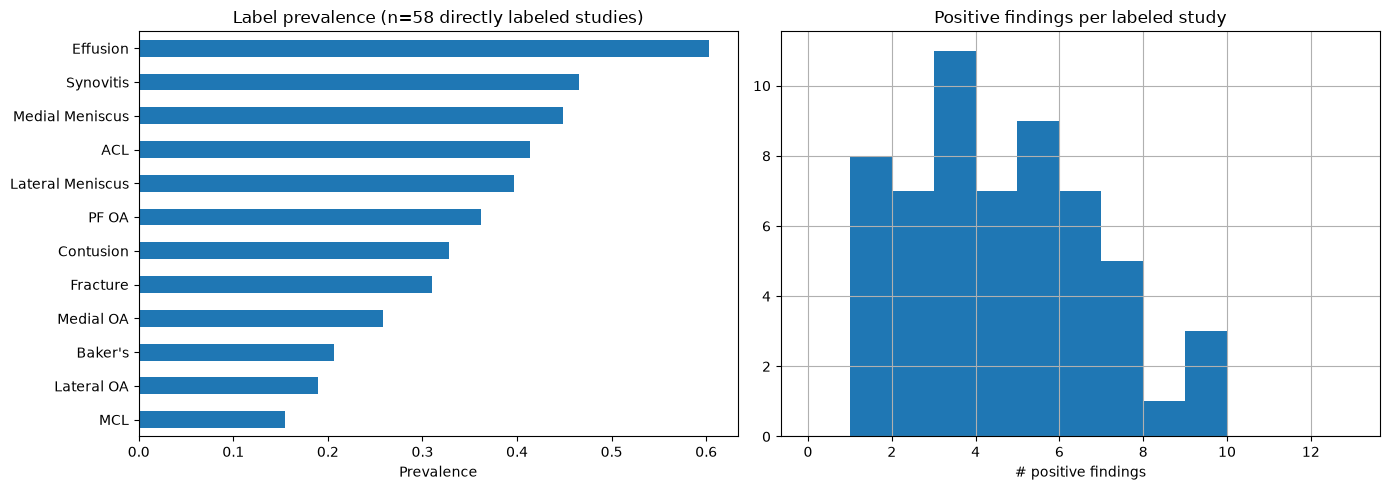

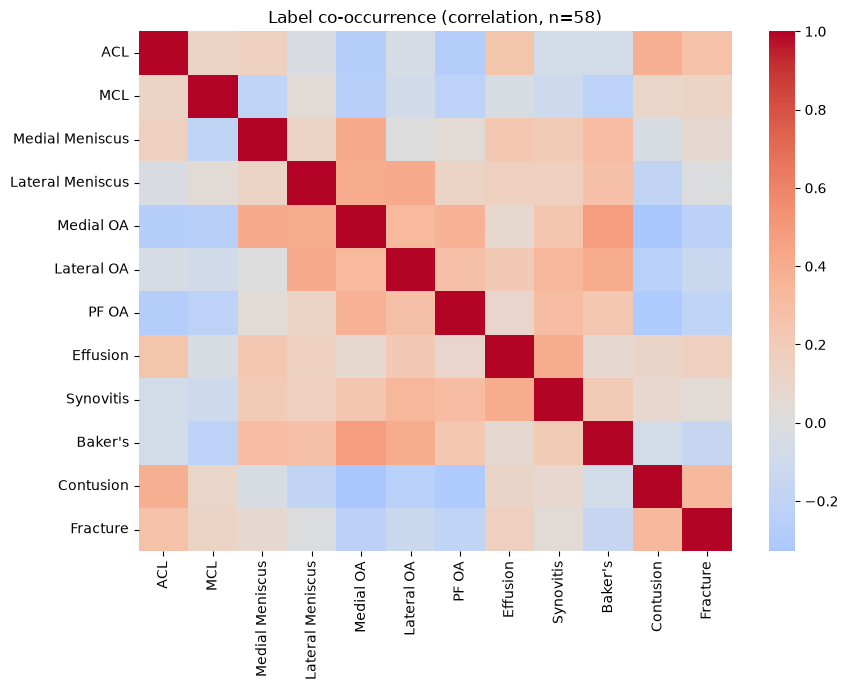

In [7]:
if n_labeled >= 5:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    prevalence.sort_values().plot(kind="barh", ax=axes[0])
    axes[0].set_title(f"Label prevalence (n={n_labeled} directly labeled studies)")
    axes[0].set_xlabel("Prevalence")

    pos_per_study.hist(bins=range(0, len(LABEL_COLS) + 2), ax=axes[1])
    axes[1].set_title("Positive findings per labeled study")
    axes[1].set_xlabel("# positive findings")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 7))
    co_occurrence = labeled_subset[LABEL_COLS].corr()
    sns.heatmap(co_occurrence, cmap="coolwarm", center=0)
    plt.title(f"Label co-occurrence (correlation, n={n_labeled})")
    plt.tight_layout()
    plt.show()
else:
    print("Labeled subset too small for meaningful visualization; skipping plots.")

## 5. Radiology Report Analysis

Descriptive only — no NLP, no extraction, no external calls. Report text stays local.

Missing reports: 0
Empty (blank-string) reports: 0
Exact duplicate reports: 131

Report length (characters):
 count    4407.000000
mean     1097.905605
std       693.948925
min        52.000000
25%       587.500000
50%       977.000000
75%      1459.500000
max      4743.000000
Name: Report, dtype: float64

Report length (words):
 count    4407.000000
mean      147.543000
std        95.329697
min         8.000000
25%        74.500000
50%       129.000000
75%       202.000000
max       690.000000
Name: Report, dtype: float64

NOTE: 131 exact-duplicate reports found. Not investigated further here — flagged as relevant context for the future weak-label generation stage (e.g. could be templated normal-exam boilerplate, or a data artifact).


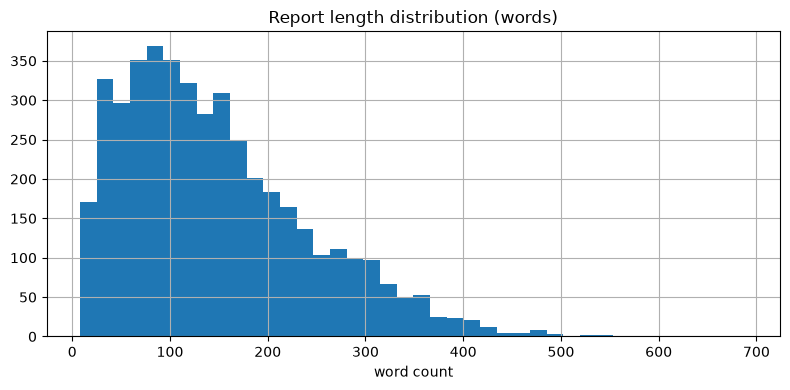

In [8]:
if "Report" in train.columns:
    n_missing_reports = train["Report"].isnull().sum()
    n_empty_reports = (train["Report"].fillna("").str.strip() == "").sum()
    report_len_chars = train["Report"].str.len()
    report_len_words = train["Report"].str.split().str.len()
    n_dup_reports = train["Report"].duplicated().sum()

    print("Missing reports:", n_missing_reports)
    print("Empty (blank-string) reports:", n_empty_reports)
    print("Exact duplicate reports:", n_dup_reports)
    print("\nReport length (characters):\n", report_len_chars.describe())
    print("\nReport length (words):\n", report_len_words.describe())

    if n_dup_reports > 0:
        print(f"\nNOTE: {n_dup_reports} exact-duplicate reports found. Not investigated further here — "
              "flagged as relevant context for the future weak-label generation stage "
              "(e.g. could be templated normal-exam boilerplate, or a data artifact).")

    plt.figure(figsize=(8, 4))
    report_len_words.hist(bins=40)
    plt.title("Report length distribution (words)")
    plt.xlabel("word count")
    plt.tight_layout()
    plt.show()
else:
    print("No 'Report' column found in train.csv.")

## 6. Series Metadata Analysis

Series per study:
 count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64


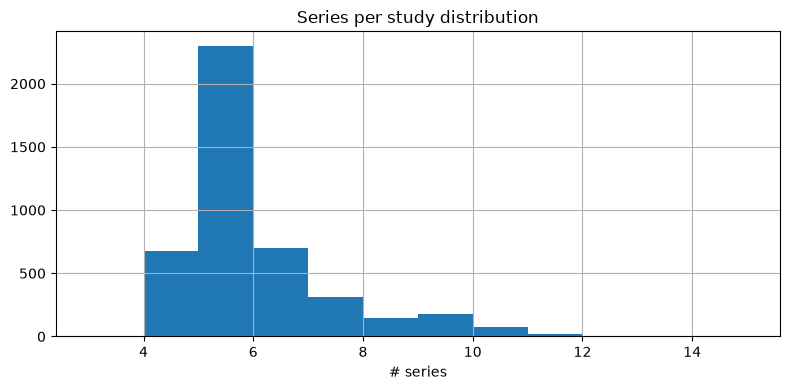


Anatomical_Plane value counts:
Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

Distinct planes observed in dataset: {'Coronal', 'Sagittal', 'Axial'}
  Studies missing plane 'Axial': 0 / 4407
  Studies missing plane 'Coronal': 0 / 4407
  Studies missing plane 'Sagittal': 0 / 4407
Studies with all 3 observed planes present: 4407 / 4407


In [9]:
series_per_study = train_series.groupby("StudyInstanceUID").size()
print("Series per study:\n", series_per_study.describe())

plt.figure(figsize=(8, 4))
series_per_study.hist(bins=range(int(series_per_study.min()), int(series_per_study.max()) + 2))
plt.title("Series per study distribution")
plt.xlabel("# series")
plt.tight_layout()
plt.show()

if "Anatomical_Plane" in train_series.columns:
    print("\nAnatomical_Plane value counts:")
    print(train_series["Anatomical_Plane"].value_counts(dropna=False))

    planes_per_study = train_series.groupby("StudyInstanceUID")["Anatomical_Plane"].apply(lambda s: set(s.dropna()))
    observed_planes = set(train_series["Anatomical_Plane"].dropna().unique())
    print("\nDistinct planes observed in dataset:", observed_planes)

    for p in sorted(observed_planes):
        missing = planes_per_study.apply(lambda s: p not in s).sum()
        print(f"  Studies missing plane '{p}': {missing} / {len(planes_per_study)}")

    all_present = planes_per_study.apply(lambda s: observed_planes.issubset(s)).sum()
    print(f"Studies with all {len(observed_planes)} observed planes present: {all_present} / {len(planes_per_study)}")

In [10]:
if {"Fluid_Sensitive", "Fat_Suppression"}.issubset(train_series.columns):
    crosstab = pd.crosstab(train_series["Fluid_Sensitive"], train_series["Fat_Suppression"])
    print("Fluid_Sensitive x Fat_Suppression crosstab:")
    print(crosstab)

    perfectly_correlated = (train_series["Fluid_Sensitive"] == train_series["Fat_Suppression"]).all()
    print("\nFluid_Sensitive == Fat_Suppression for every row:", perfectly_correlated)
    if perfectly_correlated:
        print("NOTE: the data description states these are 'not necessarily equivalent for every case.' "
              "In this copy of the training data, they are perfectly correlated with zero mixed cases. "
              "This does not contradict the documentation (which only says they're not *guaranteed* "
              "equivalent) — it just means we haven't observed a divergent case yet. Keeping both "
              "columns; not dropping either.")

Fluid_Sensitive x Fat_Suppression crosstab:
Fat_Suppression      0      1
Fluid_Sensitive              
0                10361      0
1                    0  14010

Fluid_Sensitive == Fat_Suppression for every row: True
NOTE: the data description states these are 'not necessarily equivalent for every case.' In this copy of the training data, they are perfectly correlated with zero mixed cases. This does not contradict the documentation (which only says they're not *guaranteed* equivalent) — it just means we haven't observed a divergent case yet. Keeping both columns; not dropping either.


## 7. Train/Test Structural Comparison

`test.csv` currently ships only 3 example studies. This is not enough to compare statistical distributions meaningfully — schema comparison is the only thing that can be checked reliably right now.

In [11]:
if test is not None:
    print("train.csv columns:", list(train.columns))
    print("test.csv columns:", list(test.columns))
    print(f"train.csv rows: {len(train)}, test.csv rows: {len(test)} "
          "(test.csv is an example subset, not the real held-out test set)")

if test_series is not None:
    print("\ntrain_series.csv columns:", list(train_series.columns))
    print("test_series.csv columns:", list(test_series.columns))
    schema_match = list(train_series.columns) == list(test_series.columns)
    print("train_series/test_series schema match:", schema_match)

train.csv columns: ['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
test.csv columns: ['StudyInstanceUID']
train.csv rows: 4407, test.csv rows: 3 (test.csv is an example subset, not the real held-out test set)

train_series.csv columns: ['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']
test_series.csv columns: ['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']
train_series/test_series schema match: True


## 8. Data Quality and Consistency Checks

In [12]:
quality_issues = {
    "train duplicate StudyInstanceUID": int(train["StudyInstanceUID"].duplicated().sum()),
    "train_series duplicate SeriesInstanceUID": int(train_series["SeriesInstanceUID"].duplicated().sum()),
    "orphan studies (train.csv w/o series)": len(orphans_in_train),
    "orphan studies (series w/o train.csv)": len(orphans_in_series),
    "partially labeled studies": n_partial,
    "duplicate exact reports": int(n_dup_reports) if "Report" in train.columns else None,
}

print("Data quality summary:")
for k, v in quality_issues.items():
    flag = "  <-- non-zero" if v not in (0, None) else ""
    print(f"  {k}: {v}{flag}")

Data quality summary:
  train duplicate StudyInstanceUID: 0
  train_series duplicate SeriesInstanceUID: 0
  orphan studies (train.csv w/o series): 0
  orphan studies (series w/o train.csv): 0
  partially labeled studies: 0
  duplicate exact reports: 131  <-- non-zero


## 9. Validation Feasibility

Not finalizing a validation strategy here — only documenting what grouping information is (and isn't) available.

In [13]:
grouping_keywords = ["patient", "site", "institu", "scanner", "hospital", "center", "centre"]

print("Searching all loaded tables for columns suggesting patient/site/scanner grouping info:")
for name, df in tables.items():
    matches = [c for c in df.columns if any(k in c.lower() for k in grouping_keywords)]
    print(f"  {name}: {matches if matches else 'none found'}")

print(
    "\nConclusion: no explicit patient/site/institution/scanner identifier column exists in any "
    "provided tabular file. StudyInstanceUID is the only available grouping key. Whether the same "
    "patient can appear across multiple studies cannot be determined from this data alone. "
    "This is an open dependency on DICOM-header inspection in 03_dicom_exploration.ipynb — if no "
    "patient identifier exists there either, this project will need to accept an unresolved leakage "
    "risk or fall back to non-grouped validation, and that limitation should be stated explicitly "
    "rather than assumed away."
)

Searching all loaded tables for columns suggesting patient/site/scanner grouping info:
  train: none found
  train_series: none found
  test: none found
  test_series: none found
  sample_submission: none found

Conclusion: no explicit patient/site/institution/scanner identifier column exists in any provided tabular file. StudyInstanceUID is the only available grouping key. Whether the same patient can appear across multiple studies cannot be determined from this data alone. This is an open dependency on DICOM-header inspection in 03_dicom_exploration.ipynb — if no patient identifier exists there either, this project will need to accept an unresolved leakage risk or fall back to non-grouped validation, and that limitation should be stated explicitly rather than assumed away.


## 10. Key Findings and Implications

### Confirmed Findings (verified directly from the actual data, computed above — not hardcoded)

- Schema, shapes, and ID relationships match documentation exactly: 4,407 training studies, 24,371 series, zero duplicate IDs, zero orphan records, zero train/test overlap.
- Label coverage is exactly all-or-nothing: 58/4,407 studies (1.3%) have all 12 labels; the remaining 4,349 have none. No partial-label studies exist.
- The labeled subset is genuinely multilabel (median 4 positive findings/study, range 1–9).
- Every training study contains all three anatomical planes (Sagittal, Coronal, Axial) — zero exceptions.
- `Fluid_Sensitive` and `Fat_Suppression` are perfectly correlated in this data (no mixed cases observed), even though the documentation allows for them to diverge.
- 131 exact-duplicate reports exist.
- No patient/site/institution/scanner identifier exists anywhere in the tabular metadata.

### Important Data Characteristics

- Report language is confirmed multilingual (from earlier spot-checks); this notebook does not attempt language classification.
- Series-per-study ranges from 3 to 14 (median 5) — a real design constraint for any study-level aggregation approach later.

### Data-Quality Findings

- 131 duplicate reports — flagged, not yet investigated further.
- No orphan records, no duplicate IDs, no partial labels — the tabular data is otherwise clean.

### Validation Limitations

- No grouping variable is available in the tabular data. Patient-aware or site-aware validation is not currently possible without DICOM-header inspection.

### Assumptions Confirmed

- Label coverage shape (small labeled subset, weak-supervision framing) — confirmed exactly.
- All-planes-present-per-study claim — confirmed.
- Documented schema — confirmed exactly, no surprises.

### Assumptions Still Unresolved

- Whether a study represents one knee or can include bilateral information — not resolved by tabular data; requires DICOM inspection.
- Whether the same patient appears across multiple studies — not resolved; requires DICOM inspection.

### Implications for the Next Milestone

`03_dicom_exploration.ipynb` should prioritize, in this order: (1) checking DICOM headers for any patient/site identifier absent from these CSVs, since the validation strategy depends on the answer, and (2) resolving the laterality question by inspecting actual series content — both flagged here as blocking dependencies, not optional extras.